In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("whitegrid")

In [3]:
# import dataset
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [6]:
# shape
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


`TotalCharges` must be a float. But it is Object which should be change into float

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No Null values found in dataset

Convert `TotalCharges` into float data type

In [26]:
df[df['TotalCharges'] == " "].count()

customerID          11
gender              11
SeniorCitizen       11
Partner             11
Dependents          11
tenure              11
PhoneService        11
MultipleLines       11
InternetService     11
OnlineSecurity      11
OnlineBackup        11
DeviceProtection    11
TechSupport         11
StreamingTV         11
StreamingMovies     11
Contract            11
PaperlessBilling    11
PaymentMethod       11
MonthlyCharges      11
TotalCharges        11
Churn               11
dtype: int64

In [27]:
df[df['TotalCharges'] == " "].head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No


We can notice that `TotalCharges` has blacnk spaces which can cause error while converting into float

In [5]:
# replace blank spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [6]:
# now convert into float
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'].dtypes

dtype('float64')

Hence, successfully converted `TotalCharges` into float

Churn
No     5174
Yes    1869
Name: count, dtype: int64


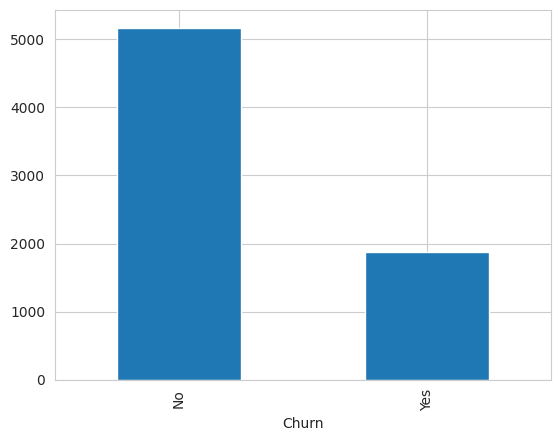

In [33]:
df['Churn'].value_counts().plot(kind="bar")
print(df['Churn'].value_counts())

From above graph we can say that the `Churn` data is imabalanced

In [35]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [7]:
cat_cols = []
num_cols = []

for cols in df.columns:
    if df[cols].dtypes == 'object':
        if cols != "customerID":
            cat_cols.append(cols)
    else:
        num_cols.append(cols)

print("categorical cols = \n", cat_cols)
print("\nNumerical cols = \n", num_cols)

categorical cols = 
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical cols = 
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


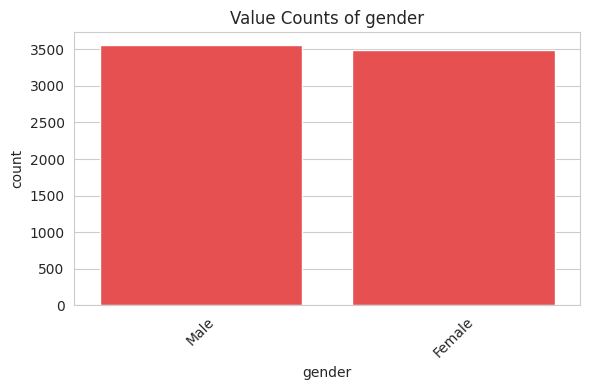

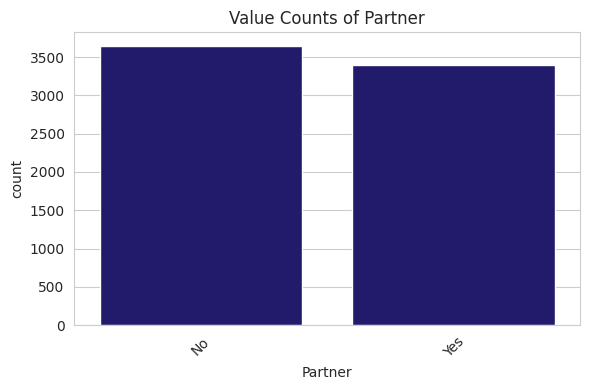

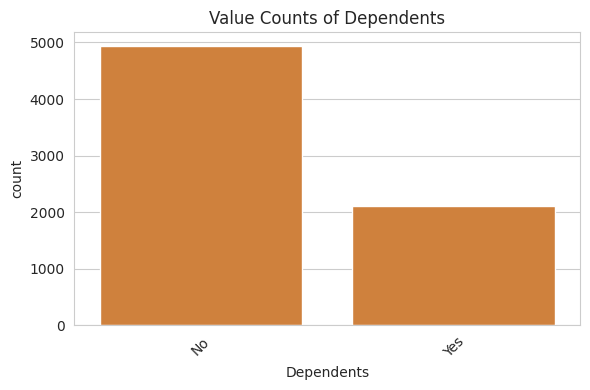

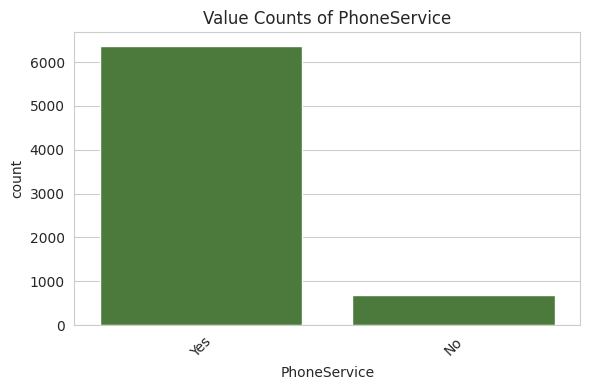

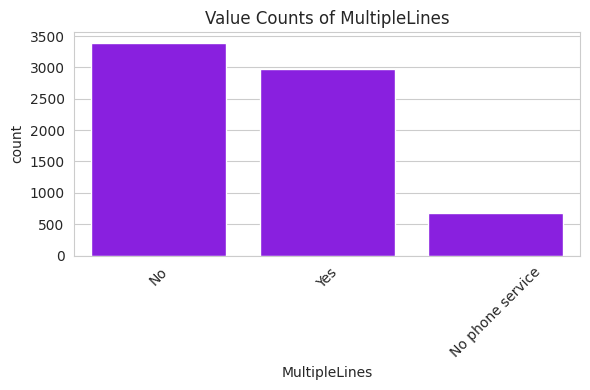

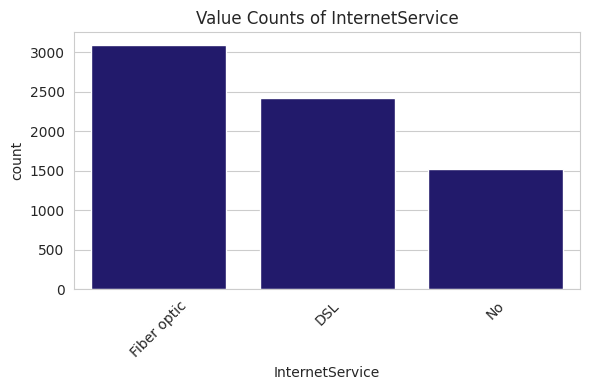

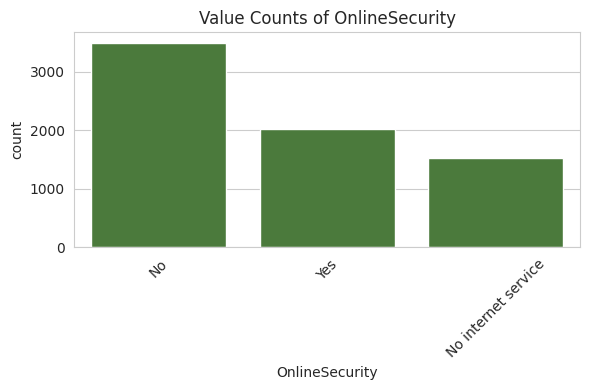

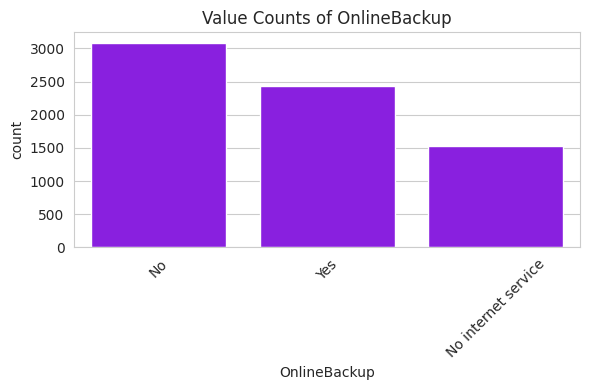

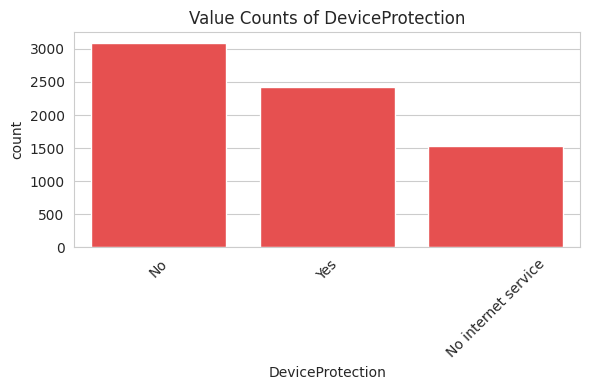

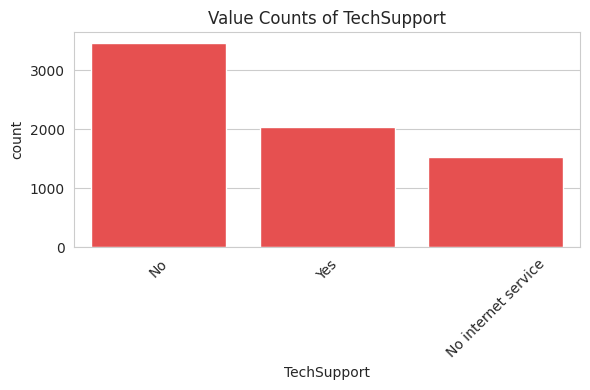

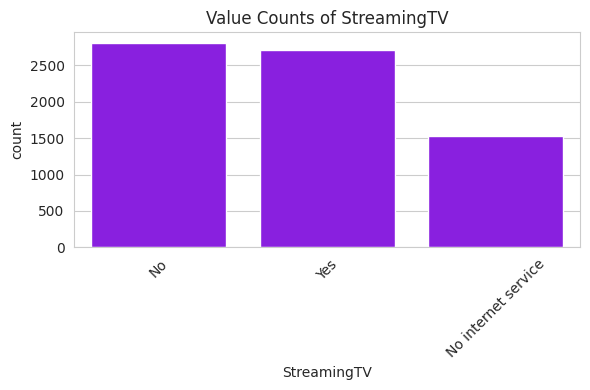

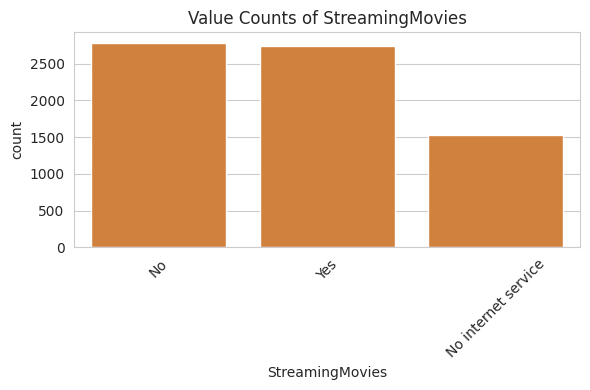

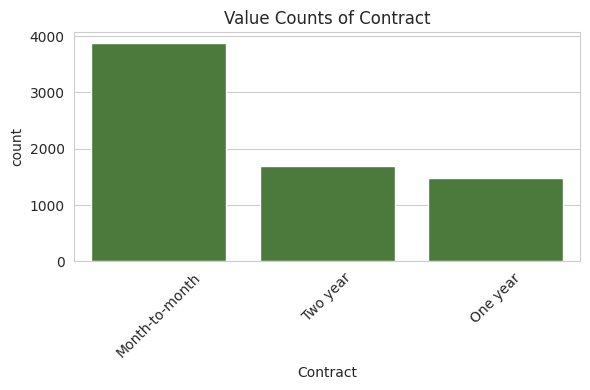

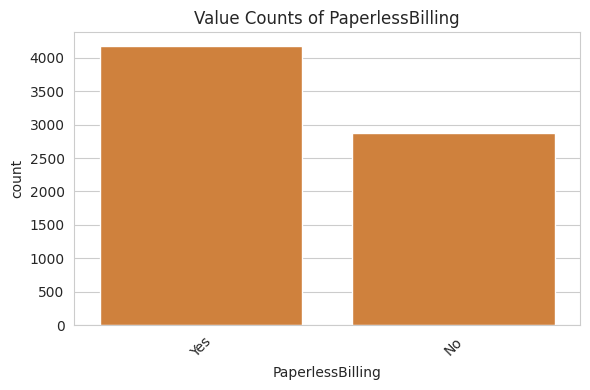

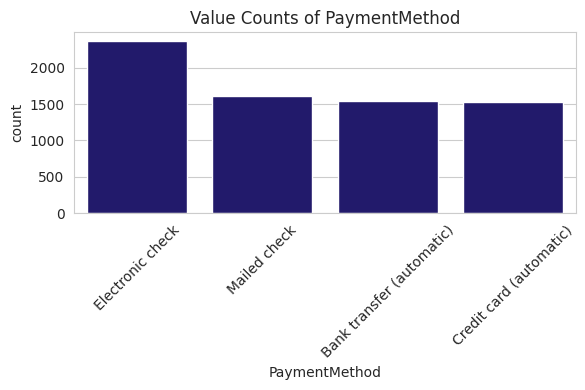

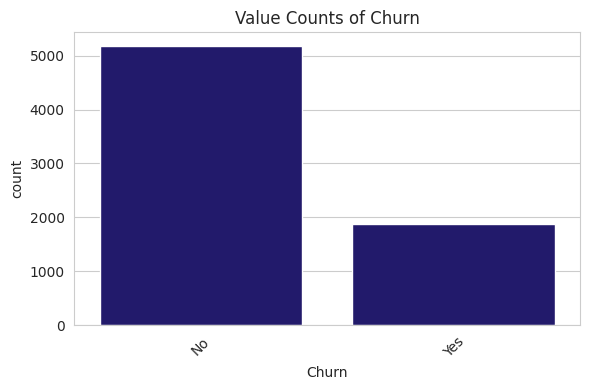

In [41]:
import random

color_lst = ['#468432', '#170C79', '#FF3737', '#E87F24', '#8C00FF']
col_lst = cat_cols

for col in col_lst:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, color=random.choice(color_lst))
    plt.title(f'Value Counts of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [45]:
avg_tenure_churn = df.groupby("Churn")["tenure"].mean().sort_values(ascending=False)
avg_tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [47]:
avg_monthlyCharges = df.groupby("Churn")['MonthlyCharges'].mean().sort_values(ascending=False)
avg_TotalCharges = df.groupby("Churn")['TotalCharges'].mean().sort_values(ascending=False)
print("average monthly charges groupby churn\n", avg_monthlyCharges)
print("\naverage total charges groupby churn\n", avg_TotalCharges)

average monthly charges groupby churn
 Churn
Yes    74.441332
No     61.265124
Name: MonthlyCharges, dtype: float64

average total charges groupby churn
 Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


In [51]:
print("Sum of total Charges (Revenue) = ", df['TotalCharges'].sum())
print("sum of tenure = ", df['tenure'].sum(), "months")

Sum of total Charges (Revenue) =  16056168.7
sum of tenure =  227990 months


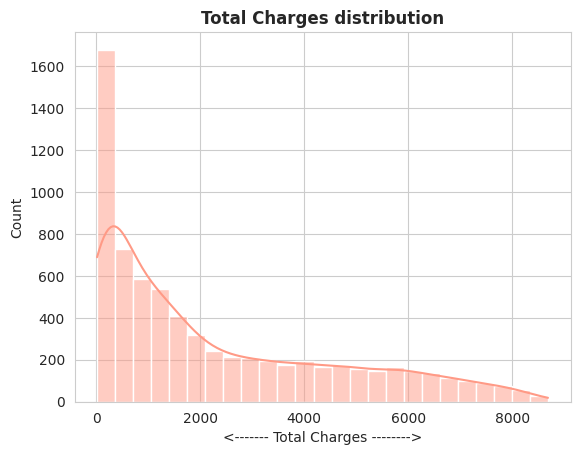

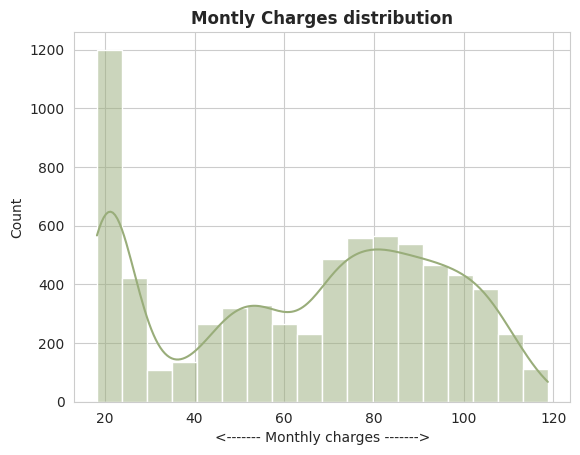

In [55]:
sns.histplot(data=df, x='TotalCharges', kde=True, color="#FF9A86")
plt.title("Total Charges distribution", weight="bold")
plt.xlabel("<------- Total Charges -------->")
plt.show()

sns.histplot(data=df, x="MonthlyCharges", kde=True, color="#99AD7A")
plt.title("Montly Charges distribution", weight="bold")
plt.xlabel("<------- Monthly charges ------->")
plt.show()

In [13]:
# print unique values from each of the categorical feature
for cols in cat_cols:
    val = df[cols].unique()
    print(f"{cols}: {val}\n")

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']



In [16]:
# convert "no' to "no Internet service" from internetService column
df['InternetService'] = df['InternetService'].replace("No", "No internet service")
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No internet service'], dtype=object)

In [21]:
churn_percent = (1869/df.shape[0]) * 100
print(f"churn percent = {churn_percent:.2f} %")

churn percent = 26.54 %


7043